In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/mall_customers_pca.csv')

In [3]:
df.head()

,PC1,PC2,PC3,PC4
0,-0.575724,-1.684874,-1.315210,-0.984750
1,-1.623595,-1.726481,-0.060149,-1.049601
2,0.279614,-1.725314,-2.182574,0.485724
3,-1.511064,-1.796205,-0.080242,0.374564
4,-0.095468,-1.707347,-0.690684,0.473954


<Axes: >

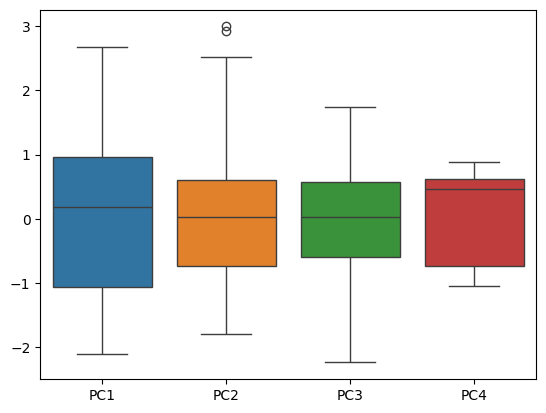

In [6]:
import seaborn as sns
sns.boxplot(data=df[['PC1', 'PC2', 'PC3', 'PC4']])

c:\Md Shahid\Liabilities\ML Algos\Clustering-with-Dimentionality_reduction\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1408: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


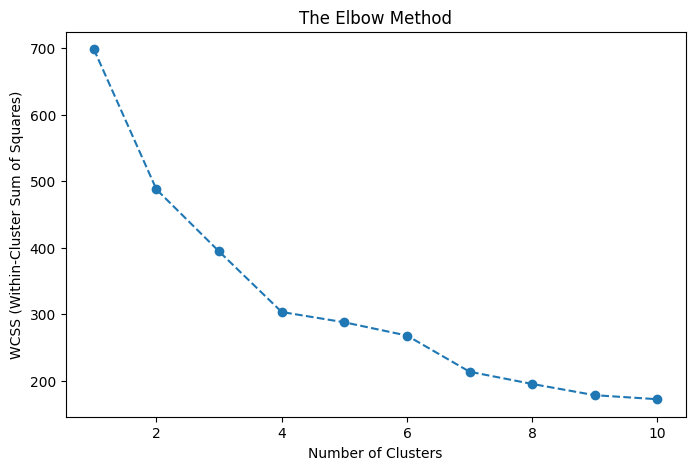

In [4]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, algorithm='elkan', random_state=4)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, algorithm='elkan', random_state=45)
y_kmeans = kmeans.fit_predict(df)

Text(0, 0.5, 'PC2')

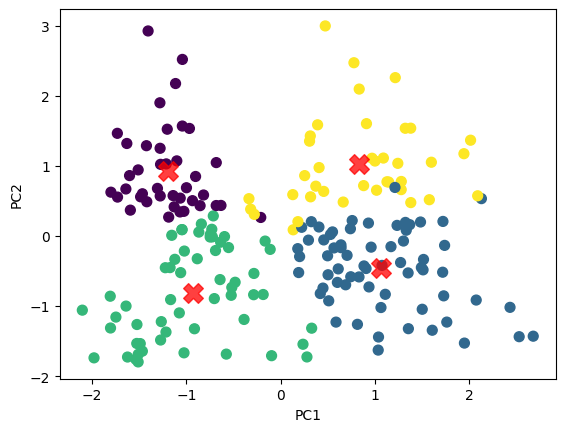

In [22]:
plt.scatter(df['PC1'], df['PC2'], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [18]:
raw_df = pd.read_csv('../data/raw/Mall_Customers.csv')
raw_df.shape

(200, 5)

In [19]:
raw_df['Cluster'] = y_kmeans
raw_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [20]:
raw_df.to_csv('../data/Clustered/mall_customers_clusters.csv', index=False)